# Code for Figure 1C

___

## Importing Libraries
___

In [1]:
# Import necessary libraries
import os
from os import listdir
from os.path import join
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import scipy.stats as stats
import seaborn as sns
from scipy.stats import mannwhitneyu


## Directories
___

In [2]:
# List of directory containing data 
current_dir = Path.cwd()
print("Current working directory:", current_dir)
data_dir = current_dir.parents[1].joinpath('raw_data', 'Figure_1F')
print("Data directory:", data_dir)
plots_dir = current_dir.parents[1].joinpath('plots', 'Figure_1F')
print("Plots directory:", plots_dir)
# List all files in the data directory
files = os.listdir(data_dir)
ratio_list = [file for file in files if file.endswith('.xlsx') and 'Ratio' in file]
print(ratio_list)

Current working directory: /Users/nzlab-la/Desktop/utag/notebooks/Figure_1
Data directory: /Users/nzlab-la/Desktop/utag/raw_data/Figure_1F
Plots directory: /Users/nzlab-la/Desktop/utag/plots/Figure_1F
['Ratio_H2B_LE_20190425_pNZ125_115.xlsx', 'Ratio_H2B_LE_20190418_pNZ121_115.xlsx', 'Ratio_H2B_LE_20190425_pNZ112_115.xlsx']


In [3]:
# Load the data from the Excel files into a dictionary of DataFrames
cells = dict()
ratio_data = []
count = 0
for file in ratio_list:
    file_path = os.path.join(data_dir, file)
    cells[count] = pd.read_excel(file_path)
    ratio_data.append(str(file_path)[-15:-5])
    count += 1

In [4]:
# collect per‐cell frames here
frames = []
for i, cell in enumerate(cells.values()):
    ratio = cell.iloc[:, 0].values
    frames.append(pd.DataFrame({
        'Construct': [ratio_data[i]] * len(ratio),
        'Ratio':      ratio
    }))
df = pd.concat(frames, ignore_index=True)

df['Construct'] = df['Construct'].replace({
    'pNZ125_115': 'Anti-Utag-FB(2E2)',
    'pNZ121_115': 'wtscFv',
    'pNZ112_115': 'Anti-Utag-FB(15F11)'
})
df['Construct'] = pd.Categorical(
    df['Construct'],
    categories=['wtscFv', 'Anti-Utag-FB(15F11)', 'Anti-Utag-FB(2E2)'],
    ordered=True
)
df = df.sort_values('Construct').reset_index(drop=True)
df 

,Construct,Ratio
0,wtscFv,0.918693
1,wtscFv,0.968161
2,wtscFv,1.004623
3,wtscFv,0.975423
4,wtscFv,0.953794
...,...,...
71,Anti-Utag-FB(2E2),1.518654
72,Anti-Utag-FB(2E2),1.865402
73,Anti-Utag-FB(2E2),3.508801
74,Anti-Utag-FB(2E2),3.254872


## Plotting
____

In [5]:
def plot_box_swarm_final_values(
    df,
    selected_field,  # e.g. "Ratio"
    figsize=(6, 4),
    xlabel="Construct",
    ylabel="Final Normalized Intensity",
    title="",
    y_min=None,
    y_max=None,
    swarm_color="black",
    tick_size=16,
    show_stats=False,
):
    """
    Creates a boxplot with whiskers and an overlaid swarmplot.
    For a DataFrame with two columns:
      - "Construct": The condition (e.g. 'wtscFv', 'Anti-Utag-FB(15F11)', 'Anti-Utag-FB(2E2)')
      - selected_field (e.g. "Ratio"): The value to plot.
      
    The final value is taken directly from each row.
    
    Optionally, if display_cell_count is True, the total number of rows is displayed in the bottom right.
    If display_error is True, error bars (SEM) are overlaid on the mean values.
    
    Parameters:
    - df: pandas DataFrame that must include at least the following columns: "Construct" and the selected_field.
    - selected_field: str, the column name to plot (e.g. "Ratio").
    - figsize: tuple, figure size.
    - xlabel: str, label for the x-axis.
    - ylabel: str, label for the y-axis.
    - title: str, plot title.
    - y_min: float, minimum y-axis limit.
    - y_max: float, maximum y-axis limit.
    - swarm_color: str or color, color of the swarmplot points.
    - tick_size: int, font size for tick labels.
    - show_stats: bool, whether to show statistical comparisons.
    
    Returns:
    - ax: matplotlib Axes object containing the plot.
    """
    sns.set_style("ticks")
    # Define the desired order for the x-axis (adjust as needed)
    order_categories = ['wtscFv', 'Anti-Utag-FB(15F11)', 'Anti-Utag-FB(2E2)']
    # Use the whole DataFrame as final_df.
    final_df = df.copy()
    # Total number of data points (rows)
    total_number = final_df.shape[0]
    # Create the figure with a white background
    plt.figure(figsize=figsize, facecolor='white')
    ax = sns.boxplot(
        x="Construct",
        y=selected_field,
        data=final_df,
        order=order_categories,
        showfliers=True,
        boxprops={'facecolor': 'white', 'edgecolor': 'black'},
        medianprops={'color': 'red'},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        linewidth=1.5,
        whis=[5, 95],  # restrict whiskers to the 5th and 95th percentiles
        width=0.5,
    )
    # print the mean and standard deviation for each category
    for category in order_categories:
        mean_value = final_df[final_df['Construct'] == category][selected_field].mean()
        std_value = final_df[final_df['Construct'] == category][selected_field].std()
        print(f"{category}: Mean = {mean_value:.2f}, Std Dev = {std_value:.2f}")
    ax.set_facecolor('white')
    # Overlay the swarmplot
    sns.swarmplot(
        x="Construct",
        y=selected_field,
        data=final_df,
        order=order_categories,
        color=swarm_color, 
        size=5,
    )
    # Set labels and title using Arial font and the provided tick size
    plt.xlabel(xlabel, fontsize=tick_size+4, fontname="Arial", color='black')
    plt.ylabel(ylabel, fontsize=tick_size+4, fontname="Arial", color='black')
    plt.title(title, fontsize=tick_size+4, fontname="Arial", color='black') 
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    ax.tick_params(axis='x', labelsize=tick_size+4, colors='black')
    ax.tick_params(axis='y', labelsize=tick_size, colors='black')
    plt.xticks(fontname="Arial")
    plt.yticks(fontname="Arial")
    # change the x axis labels to be the same as the order_categories
    new_labels = ['wtscFv', 'Anti-Utag-FB \n (15F11)', 'Anti-Utag-FB \n (2E2)']
    ax.set_xticks(range(len(order_categories)))
    ax.set_xticklabels(new_labels, fontsize=tick_size, fontname="Arial", color='black')
    if show_stats:
        # Compute global statistics from the entire data (final_df)
        global_max = 7#final_df[selected_field].max()
        global_min = final_df[selected_field].min()
        global_range = global_max - global_min
        
        offset = 0.1 * global_range  # Each comparison will be offset by this amount
        bar_height = 0.02 * global_range  # Height for the significance line
        comparisons = [((0, 1), 0),((0, 2), 1), ((1, 2), 2)]
        for ((i, j), level) in comparisons:
            group1 = final_df[final_df['Construct'] == order_categories[i]][selected_field]
            group2 = final_df[final_df['Construct'] == order_categories[j]][selected_field]
            stat, p = mannwhitneyu(group1, group2)
            # Determine significance annotation
            if p < 0.0001:
                sig = '****'
            elif p < 0.001:
                sig = '***'
            elif p < 0.01:
                sig = '**'
            elif p < 0.05:
                sig = '*'
            else:
                sig = 'ns'
            # x positions for the two groups (assumed to be 0,1,2)
            x1, x2 = i, j
            # Set the significance bar y position as global_max plus an offset based on level:
            y_line = global_max + offset * (level *1.5)
            # Draw the bar with a small height
            ax.plot([x1, x1, x2, x2], [y_line, y_line + bar_height, y_line + bar_height, y_line], 
                    lw=1.5, c='k')
            # Place the significance text in the middle above the bar.
            ax.text((x1 + x2) * 0.5, y_line + bar_height, sig, ha='center', va='bottom', 
                    color='k', fontsize=tick_size, fontname="Arial")
            print(f"Comparison {order_categories[i]} vs {order_categories[j]}: p-value = {p:.2e}")
    plt.tight_layout()
    # save as png and svg with a min of 600 dpi in the results dir
    plt.savefig(plots_dir / f"box_swarm_{selected_field}.png", dpi=600, bbox_inches='tight') 
    plt.savefig(plots_dir / f"box_swarm_{selected_field}.svg", dpi=600, bbox_inches='tight')
    plt.show()
    return ax

wtscFv: Mean = 0.95, Std Dev = 0.04
Anti-Utag-FB(15F11): Mean = 3.38, Std Dev = 1.71
Anti-Utag-FB(2E2): Mean = 1.92, Std Dev = 0.77
Comparison wtscFv vs Anti-Utag-FB(15F11): p-value = 1.38e-09
Comparison wtscFv vs Anti-Utag-FB(2E2): p-value = 4.85e-09
Comparison Anti-Utag-FB(15F11) vs Anti-Utag-FB(2E2): p-value = 3.13e-05


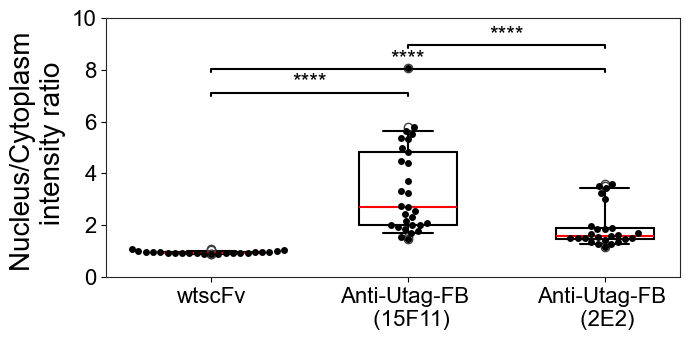

<Axes: ylabel='Nucleus/Cytoplasm \n intensity ratio'>

In [6]:
plot_box_swarm_final_values(
    df,
    selected_field='Ratio',
    figsize=(7, 3.5), 
    xlabel=None,
    ylabel="Nucleus/Cytoplasm \n intensity ratio",
    title="",
    y_min=0,
    y_max=10,
    swarm_color="black",
    tick_size=16,
    show_stats=True,
    )